In [21]:

from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/Colab Notebooks/DAT103_Indonesia_Project'
AOI_BBOX = {
    'min_lon': 107.2831,
    'max_lon': 107.3471,
    'min_lat': -6.7023,
    'max_lat': -6.6383
}
LANDSAT_DIR= f'{BASE}/data/landsat/'
LULC_DIR=f'{BASE}/data/lulc/'
PROCESSED_DIR= f'{BASE}/data/processed/'
PATCHES_DIR=f'{BASE}/data/patches/'
MODELS_DIR=f'{BASE}/models/'
FIGURES_DIR =f'{BASE}/figures/'
import os
for d in [LANDSAT_DIR, LULC_DIR, PROCESSED_DIR, PATCHES_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)
print("Paths ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths ready.


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import rasterio
import numpy as np
import glob
import matplotlib.pyplot as plt
bands = {}
ref_profile = None
ref_shape   = None

for b_num in [2, 3, 4, 5, 6, 7]:
    path = glob.glob(f"{LANDSAT_DIR}/*_B{b_num}.TIF")[0]
    with rasterio.open(path) as src:
        raw = src.read(1).astype(float)
        bands[f'B{b_num}'] = raw * 0.0000275 - 0.2
        if b_num == 4:
            ref_profile = src.profile
            ref_shape   = src.shape
# using the file form member 3
with rasterio.open(f"{PROCESSED_DIR}/ndvi.tif") as src:
    ndvi = src.read(1).astype(float)
H, W = ref_shape
print(f"Image size: {H} rows × {W} cols")

image_stack = np.stack([
    bands['B2'], bands['B3'], bands['B4'],
    bands['B5'], bands['B6'], bands['B7'],
    ndvi
], axis=0)
print(f"Image stack shape: {image_stack.shape}")   # Expected: (7, H, W)

Image size: 237 rows × 237 cols
Image stack shape: (7, 237, 237)


In [24]:
norm_stack = np.zeros_like(image_stack)
for i in range(image_stack.shape[0]):
    band  = image_stack[i]
    valid = ~np.isnan(band) & (band > -0.2)
    mean  = band[valid].mean()
    std   = band[valid].std() + 1e-8
    norm_stack[i] = (band - mean) / std
    print(f"Channel {i+1}: mean={mean:.4f}, std={std:.4f}")
norm_stack = np.nan_to_num(norm_stack, nan=0.0)
print(f"\nNormalized stack shape: {norm_stack.shape}")

Channel 1: mean=0.0539, std=0.0506
Channel 2: mean=0.0757, std=0.0514
Channel 3: mean=0.0667, std=0.0563
Channel 4: mean=0.3014, std=0.0943
Channel 5: mean=0.1955, std=0.0729
Channel 6: mean=0.1054, std=0.0586
Channel 7: mean=0.6226, std=0.1931

Normalized stack shape: (7, 237, 237)


In [25]:
import rasterio
from rasterio.warp import reproject, Resampling
from sklearn.model_selection import train_test_split
import numpy as np
import glob

PATCH_SIZE = 64
STRIDE     = 8
lulc_path = glob.glob(f"{LULC_DIR}/*.tif")[0]
with rasterio.open(lulc_path) as src_lulc:
    lulc_raw = src_lulc.read(1)
    lulc_reprojected = np.zeros(ref_shape, dtype=lulc_raw.dtype)
    reproject(
        source=lulc_raw,
        destination=lulc_reprojected,
        src_transform=src_lulc.transform,
        src_crs=src_lulc.crs,
        dst_transform=ref_profile['transform'],
        dst_crs=ref_profile['crs'],
        resampling=Resampling.nearest
    )

def extract_patches(img_stack, mask_img):
    """Helper function to extract patches from the entire provided map"""
    p_X, p_y, p_coords = [], [], []

    channels, h, w = img_stack.shape

    for i in range(0, h - PATCH_SIZE + 1, STRIDE):
        for j in range(0, w - PATCH_SIZE + 1, STRIDE):
            patch = img_stack[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
            label = mask_img[i:i+PATCH_SIZE, j:j+PATCH_SIZE]

            if np.count_nonzero(label) < (PATCH_SIZE * PATCH_SIZE * 0.2):
                continue

            p_X.append(patch)
            p_y.append(label)
            p_coords.append((i, j))

    return np.array(p_X, dtype=np.float32), np.array(p_y, dtype=np.int64), np.array(p_coords)

print("Extracting ALL possible patches from the full image...")
X_full, y_full, c_full = extract_patches(norm_stack, lulc_reprojected)

X_train_val, X_test, y_train_val, y_test, c_train_val, c_test = train_test_split(
    X_full, y_full, c_full, test_size=0.15, random_state=42, shuffle=True
)

X_train, X_val, y_train, y_val, c_train, c_val = train_test_split(
    X_train_val, y_train_val, c_train_val, test_size=0.18, random_state=42, shuffle=True
)

print(f"\nTotal Patches Extracted: {len(X_full)}")
print(f"Final Train Set : {len(X_train)} patches")
print(f"Final Val Set   : {len(X_val)} patches")
print(f"Final Test Set  : {len(X_test)} patches")


Extracting ALL possible patches from the full image...

Total Patches Extracted: 484
Final Train Set : 337 patches
Final Val Set   : 74 patches
Final Test Set  : 73 patches


In [26]:
np.save(f"{PATCHES_DIR}/X_train.npy",      X_train)
np.save(f"{PATCHES_DIR}/y_train.npy",      y_train)
np.save(f"{PATCHES_DIR}/X_val.npy",        X_val)
np.save(f"{PATCHES_DIR}/y_val.npy",        y_val)
np.save(f"{PATCHES_DIR}/X_test.npy",       X_test)
np.save(f"{PATCHES_DIR}/y_test.npy",       y_test)
np.save(f"{PATCHES_DIR}/train_coords.npy", c_train)
np.save(f"{PATCHES_DIR}/test_coords.npy",  c_test)
print("All 8 .npy files saved to", PATCHES_DIR)

All 8 .npy files saved to /content/drive/MyDrive/Colab Notebooks/DAT103_Indonesia_Project/data/patches/


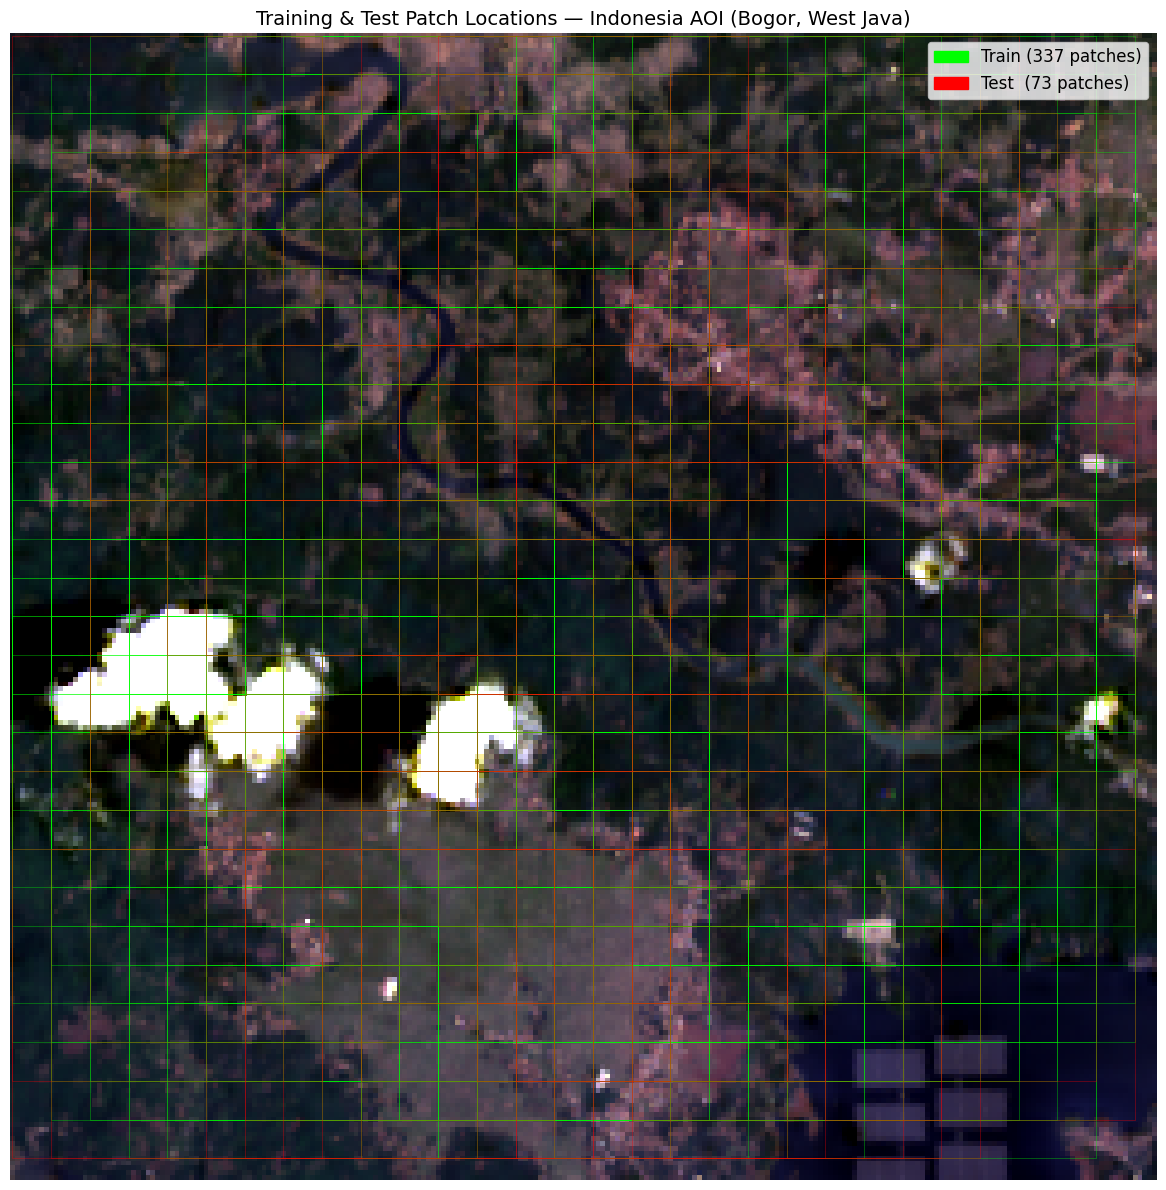

Saved patch_overlay.png to figures/


In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
def pct_normalize(b):
    p2, p98 = np.percentile(b[b > 0], [2, 98])
    return np.clip((b - p2) / (p98 - p2), 0, 1)
rgb = np.dstack([
    pct_normalize(np.nan_to_num(bands['B4'])),   # Red
    pct_normalize(np.nan_to_num(bands['B3'])),   # Green
    pct_normalize(np.nan_to_num(bands['B2']))    # Blue
])
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(rgb)
for (row, col) in c_train:
    rect = plt.Rectangle(
        (col, row), PATCH_SIZE, PATCH_SIZE,
        edgecolor='lime', facecolor='none', lw=0.4, alpha=0.6
    )
    ax.add_patch(rect)
for (row, col) in c_test:
    rect = plt.Rectangle(
        (col, row), PATCH_SIZE, PATCH_SIZE,
        edgecolor='red', facecolor='none', lw=0.4, alpha=0.6
    )
    ax.add_patch(rect)

legend_handles = [
    Patch(facecolor='lime', edgecolor='lime', label=f'Train ({len(c_train)} patches)'),
    Patch(facecolor='red',  edgecolor='red',  label=f'Test  ({len(c_test)} patches)')
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=12)
ax.set_title("Training & Test Patch Locations — Indonesia AOI (Bogor, West Java)", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/patch_overlay.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved patch_overlay.png to figures/")

In [29]:
import os
print("=== Output verification ===")
expected_files = [
    "X_train.npy", "y_train.npy",
    "X_val.npy",   "y_val.npy",
    "X_test.npy",  "y_test.npy",
    "train_coords.npy", "test_coords.npy"
]
for f in expected_files:
    path = f"{PATCHES_DIR}/{f}"
    exists = os.path.exists(path)
    size   = os.path.getsize(path) // 1024 if exists else 0
    status =  ""if exists else " MISSING"
    print(f"  {status}  {f}  ({size} KB)")
print("\nDONE")

=== Output verification ===
    X_train.npy  (37744 KB)
    y_train.npy  (10784 KB)
    X_val.npy  (8288 KB)
    y_val.npy  (2368 KB)
    X_test.npy  (8176 KB)
    y_test.npy  (2336 KB)
    train_coords.npy  (5 KB)
    test_coords.npy  (1 KB)

DONE
